**Week 9 Independent Lab**

# Inferential Statistics

Author: Magdalena Gerharter  
Course: BGEN 632 Grad. Intro. to Python  
Term: Spring 2025

## Import Modules

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sts # for QQ plot
from scipy.stats import pearsonr # correlation p-values
from sklearn.linear_model import LinearRegression # regression output
import statsmodels.formula.api as smf # ols regression
from datetime import date

## Set working directory

In [12]:
os.chdir("/Users/magdalenagerharter/Documents/GitHub/week9labs/data")
os.getcwd()  #confirm change

'/Users/magdalenagerharter/Documents/GitHub/week9labs/data'

In [47]:
data = pd.read_csv("ect_data.txt", delimiter = "\t")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   attitude1_01  201 non-null    int64
 1   attitude1_02  201 non-null    int64
 2   attitude1_03  201 non-null    int64
 3   attitude1_04  201 non-null    int64
 4   intent1_01    201 non-null    int64
 5   intent1_02    201 non-null    int64
 6   intent1_03    201 non-null    int64
 7   intent1_04    201 non-null    int64
 8   peruse01      201 non-null    int64
 9   peruse02      201 non-null    int64
 10  peruse03      201 non-null    int64
 11  peruse04      201 non-null    int64
 12  satis01       201 non-null    int64
 13  satis02       201 non-null    int64
 14  satis03       201 non-null    int64
 15  satis04       201 non-null    int64
dtypes: int64(16)
memory usage: 25.3 KB


## Linear and Multiple Regression

In [57]:
ind_var = ['attitude1_01', 'attitude1_02', 'attitude1_03', 'peruse01', 'peruse02']
X = data[ind_var]
Y = data['intent1_01']

### Check linearity

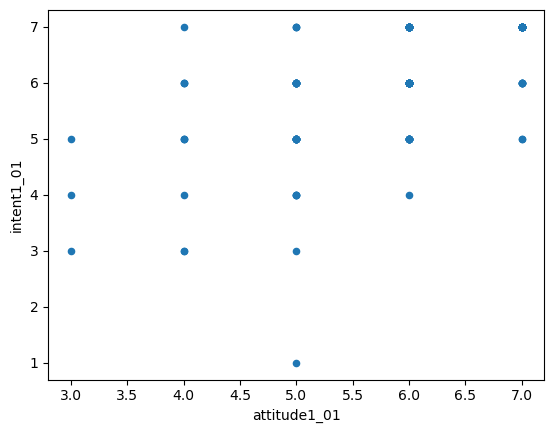

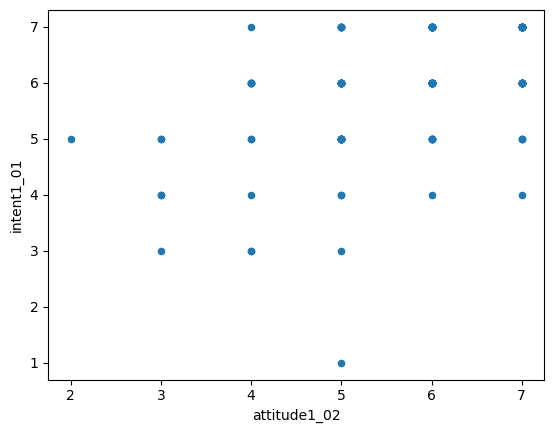

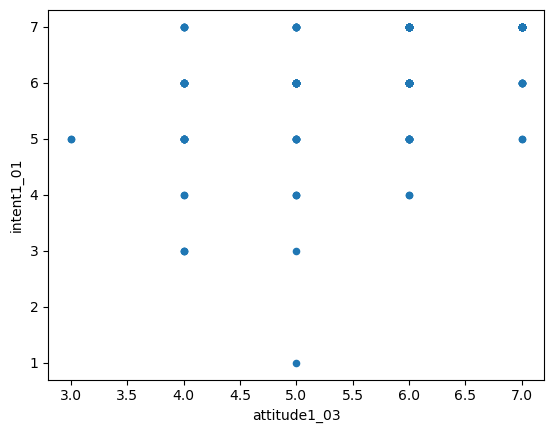

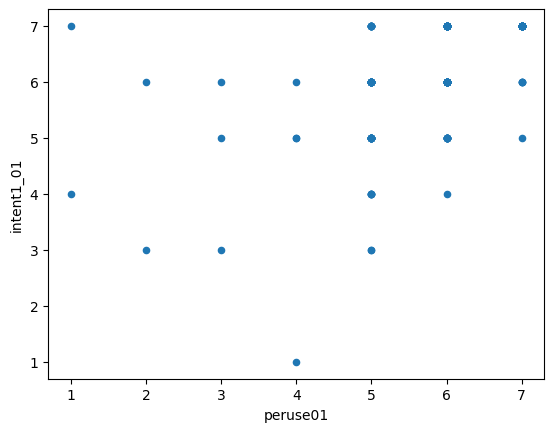

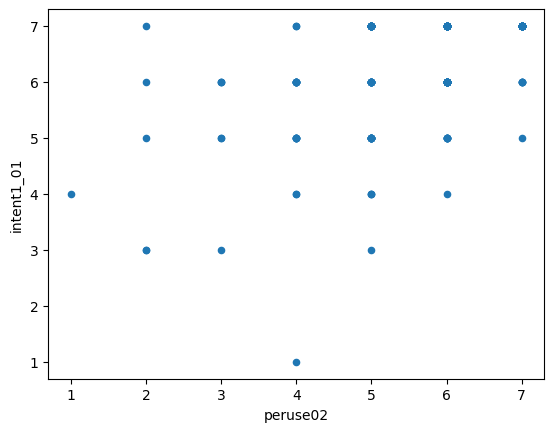

In [70]:
for var in ind_var:
    data.plot.scatter(x=var, y='intent1_01')

### Check correlation

In [72]:
data[ind_var + ['intent1_01']].corr()

,attitude1_01,attitude1_02,attitude1_03,peruse01,peruse02,intent1_01
attitude1_01,1.000000,0.781832,0.748347,0.576265,0.593120,0.666356
attitude1_02,0.781832,1.000000,0.660611,0.480259,0.547582,0.603616
attitude1_03,0.748347,0.660611,1.000000,0.453128,0.483051,0.519099
peruse01,0.576265,0.480259,0.453128,1.000000,0.746810,0.566642
peruse02,0.593120,0.547582,0.483051,0.746810,1.000000,0.529681
intent1_01,0.666356,0.603616,0.519099,0.566642,0.529681,1.000000


### Check Homoscedasticity

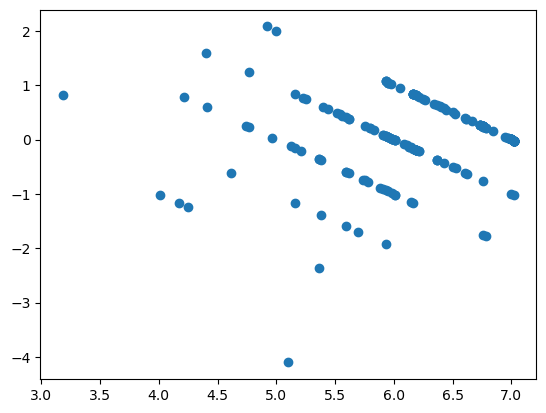

In [76]:
lin_reg = smf.ols('intent1_01 ~ attitude1_01 + attitude1_02 + attitude1_03 + peruse01 + peruse02', data=data).fit()

plt.scatter(lin_reg.fittedvalues, lin_reg.resid)

### Check Independence

In [83]:
lin_reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             intent1_01   R-squared:                       0.509
Model:                            OLS   Adj. R-squared:                  0.496
Method:                 Least Squares   F-statistic:                     40.37
Date:                Tue, 29 Apr 2025   Prob (F-statistic):           2.23e-28
Time:                        23:42:13   Log-Likelihood:                -217.26
No. Observations:                 201   AIC:                             446.5
Df Residuals:                     195   BIC:                             466.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        1.2145      0.359      3.383      0.001       0.506       1.923
attitude1_01     0.3928      0.107      3.684      0.000       0.182       0.603
attitude1_02     0.1782      0.079      2.260      0.025       0.023       0.334
attitude1_03    -0.0006      0.073     -0.008      0.994      -0.145       0.144
peruse01         0.2351      0.074      3.177      0.002       0.089       0.381
peruse02         0.0236      0.067      0.351      0.726      -0.109       0.156
==============================================================================
Omnibus:                       67.616   Durbin-Watson:                   1.887
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              315.806
Skew:                          -1.216   Prob(JB):                     2.65e-69
Kurtosis:                       8.638   Cond. No.                         94.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Check Normality

((array([-2.70235077, -2.39300644, -2.21670641, -2.09047253, -1.99075721,
         -1.90762425, -1.83590295, -1.77254445, -1.71559368, -1.66371874,
         -1.61596971, -1.57164427, -1.53020786, -1.49124379, -1.45442067,
         -1.41947039, -1.38617282, -1.35434495, -1.32383285, -1.29450578,
         -1.26625169, -1.2389738 , -1.21258791, -1.18702027, -1.1622059 ,
         -1.13808725, -1.11461308, -1.09173755, -1.06941949, -1.04762177,
         -1.02631079, -1.005456  , -0.98502958, -0.96500611, -0.94536226,
         -0.92607659, -0.90712937, -0.88850233, -0.87017859, -0.85214246,
         -0.83437937, -0.81687572, -0.79961884, -0.78259687, -0.76579869,
         -0.74921388, -0.73283263, -0.71664571, -0.70064443, -0.68482057,
         -0.66916635, -0.65367443, -0.63833783, -0.62314992, -0.60810442,
         -0.59319534, -0.57841696, -0.56376385, -0.5492308 , -0.53481284,
         -0.52050522, -0.50630336, -0.49220289, -0.47819962, -0.4642895 ,
         -0.45046865, -0.43673331, -0.

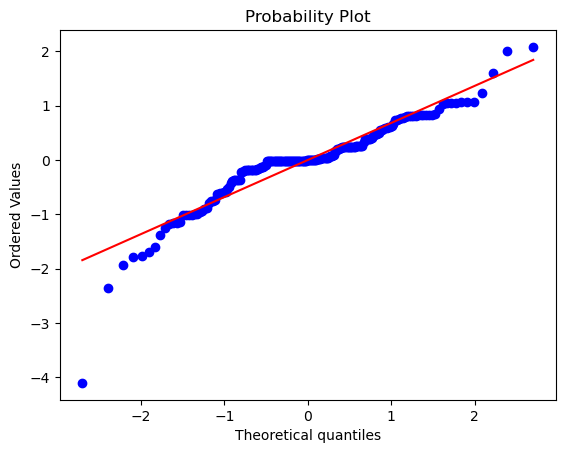

In [86]:
sts.probplot(lin_reg.resid, dist="norm", plot=plt)

## F- & T-Test

### F-Test  
F-statistic: 40.37  
p-value (Prob (F-statistic)): 2.23e-28  
F-statistic is quite large, and the p-value is extremely small. This shows that the overall model is statistically significant, meaning at least one of the predictors has an impact on the dependent variable (intent1_01).  

### T-Tests  
t-statistic: This tells us how many standard errors the estimated coefficient is from zero.  
p-value (P>|t|): This tells us the probability of the coefficient being equal to zero (null hypothesis).  

#### Significant Variables:
*attitude1_01:*  
    t-statistic: 3.684  
    p-value: 0.000  
    p-value < 0.05 => statistically significant  
*attitude1_02:*  
    t-statistic: 2.260  
    p-value: 0.025  
    p-value < 0.05 => statistically significant  
*peruse01:*  
    t-statistic: 3.177  
    p-value: 0.002  
    p-value < 0.05 => statistically significant  

#### Non-Significant Variables:  
*attitude1_03:*  
    t-statistic: -0.008  
    p-value: 0.994  
    p-value > 0.05 => not statistically significant  
*peruse02:*  
    t-statistic: 0.351  
    p-value: 0.726  
    p-value > 0.05 => not statistically significant  


### Two Significant Variables & Their Business Significance  
**Consumer attitude**  
How people feel about a product or service is crucial for whether they’ll buy it. A positive attitude can lead to more sales, repeat customers, and brand loyalty. Understanding consumer attitudes helps businesses decide how to market and position their products.  
  
**Engagement time**  
The more time people spend looking at a product or website, the more likely they are to make a purchase. Businesses can use this info to improve website design, create better user experiences, and target ads or offers to encourage sales.

## Equation for Model  

*Y* =  
>Intercept coef +  
>(attitude1_01 coef * attitude1_01) +  
>(attitude1_02 coef * attitude1_02) +  
>(attitude1_03 coef * attitude1_03) +  
>(peruse01 coef * peruse01) +  
>(peruse02 coef * peruse02)  

    
*intent1_01* =  
>1.2145 +  
>(0.3928 * attitude1_01) +  
>(0.1782 * attitude1_02) +  
>(-0.0006 * attitude1_03) +  
>(0.2351 * peruse01) +  
>(0.0236 * peruse02)  


**Interpretation**  
The equation predicts purchase intent (intent1_01) based on how consumers feel about the product (attitude1_01 and attitude1_02) and how much time they spend looking at it (peruse01), starting at 1.2145 when everything else is zero, with attitude1_03 and peruse02 having little to no effect.

## Additional Resources  

https://www.w3schools.com/python/pandas/pandas_ref_dataframe.asp 

Statistics Script from my University back home
[Statistics Script](/Users/magdalenagerharter/Documents/GitHub/week9labs/files/StatistikBuch.pdf)